#### 13.6 目标检测数据集
该数据集包含1000张不同角度和大小的香蕉图片。
##### 13.6.1下载数据集

In [1]:
import os
import pandas as pd
import torch
import torchvision
from d2l import torch as d2l
#@save
d2l.DATA_HUB['banana-detection'] = (
    d2l.DATA_URL + 'banana-detection.zip',
    '5de26c8fce5ccdea9f91267273464dc968d20d72')

##### 16.6.2 读取数据集
读取数据集，包含一个.csv文件，含目标类别标签和真实边界框坐标。

In [2]:
#@save
def read_data_bananas(is_train=True):
    """读取香蕉检测数据集中的图像和标签"""
    data_dir = d2l.download_extract('banana-detection')
    csv_fname = os.path.join(data_dir, 'bananas_train' if is_train
                             else 'bananas_val', 'label.csv')
    csv_data = pd.read_csv(csv_fname)
    csv_data = csv_data.set_index('img_name')
    images, targets = [], []
    for img_name, target in csv_data.iterrows():
        images.append(torchvision.io.read_image(
            os.path.join(data_dir, 'bananas_train' if is_train else
                         'bananas_val', 'images', f'{img_name}')))
        # 这里的target包含（类别，左上角x，左上角y，右下角x，右下角y），
        # 其中所有图像都具有相同的香蕉类（索引为0）
        targets.append(list(target))
    return images, torch.tensor(targets).unsqueeze(1) / 256

```BananasDataset```类创建一个自定义```Dataset```实例来加载数据集。

In [3]:
#@save
class BananasDataset(torch.utils.data.Dataset):
    """一个用于加载香蕉检测数据集的自定义数据集"""
    def __init__(self, is_train):
        self.features, self.labels = read_data_bananas(is_train)
        print('read ' + str(len(self.features)) + (f' training examples' if
              is_train else f' validation examples'))

    def __getitem__(self, idx):
        return (self.features[idx].float(), self.labels[idx])

    def __len__(self):
        return len(self.features)

定义```load_data_bananas()```，为训练集和测试集返回两个数据加载器实例，测试集需要打乱数据。

In [4]:
#@save
def load_data_bananas(batch_size):
    """加载香蕉检测数据集"""
    train_iter = torch.utils.data.DataLoader(BananasDataset(is_train=True),
                                             batch_size, shuffle=True)
    val_iter = torch.utils.data.DataLoader(BananasDataset(is_train=False),
                                           batch_size)
    return train_iter, val_iter

读取一个小批量，其形状为(批量大小,通道数,高度,宽度)。每个边界框的标签用长度为5的数组表示，第一个元素时边界框目标的类别，-1表示用于填充的非法边界框，其余四个元素为边界框左上角和右下角的坐标值$(x,y),x,y\in[0,1]$。

In [5]:
batch_size, edge_size = 32, 256
train_iter, _ = load_data_bananas(batch_size)
batch = next(iter(train_iter))
batch[0].shape, batch[1].shape

read 1000 training examples
read 100 validation examples


(torch.Size([32, 3, 256, 256]), torch.Size([32, 1, 5]))

##### 13.6.3 演示

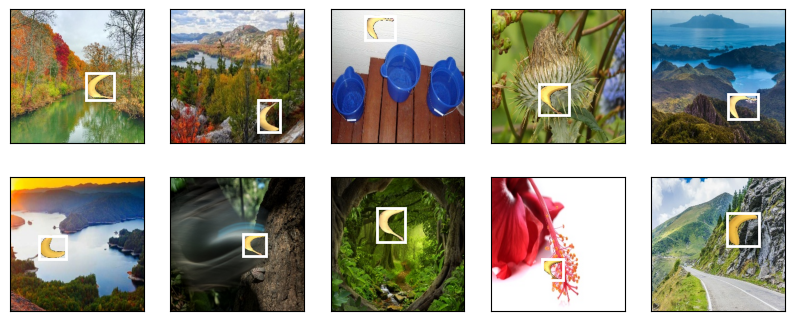

In [6]:
imgs = (batch[0][0:10].permute(0, 2, 3, 1)) / 255
axes = d2l.show_images(imgs, 2, 5, scale=2)
for ax, label in zip(axes, batch[1][0:10]):
    d2l.show_bboxes(ax, [label[0][1:5] * edge_size], colors=['w'])

#### 13.7 单发多框检测（SSD）
##### 13.7.1 模型
单发多框检测模型主要由一个基础网络块和若干多尺度特征块组成。
1. 类别预测层

加假设目标类别的数量为$q$，0类是背景，在某个尺度下，加色和特征图的高和宽分别为$h$和$w$，如果以其中每个单元为中心生成$a$个描框，则需要对$a\cdot h\cdot w$个描框进行分类，进而使用卷积层的通道来输出类别预测，降低模型复杂度。类比预测层使用一个保持输入的宽度和高度不变的卷积层，输出和输入在特征图的宽和高上的空间坐标一一对应。

In [13]:
import torchvision
from torch import nn
from torch.nn import functional as F
def cls_predictor(num_inputs, num_anchors, num_classes):
    return nn.Conv2d(num_inputs, num_anchors * (num_classes + 1), kernel_size=3, padding=1)

2. 边界框预测层

边界框预测层与类别预测层类似，但这里需要为每个描框预测4个偏移量。

In [43]:
def bbox_predictor(num_inputs, num_anchors):
    return nn.Conv2d(num_inputs, num_anchors * 4, kernel_size=3, padding=1)

3. 连接多尺度的预测

不同尺度下预测输出的形状有可能不同。为同一个小批量构建两个不同比例的特征图（Y1和Y2），其中Y2的高宽是Y1的一半，输出形状是(批量大小,高度,高度,宽度)。

In [44]:
def forward(x, block):
    return block(x)

Y1 = forward(torch.zeros((2, 8, 20, 20)), cls_predictor(8, 5, 10))
Y2 = forward(torch.zeros((2, 16, 10, 10)), cls_predictor(16, 3, 10))
Y1.shape, Y2.shape

(torch.Size([2, 55, 20, 20]), torch.Size([2, 33, 10, 10]))

将预测结果转换为二维格式(批量大小,高度×宽度×通道数)，以便之后在维度1上的连接。

In [42]:
def flatten_pred(pred):
    return torch.flatten(pred.permute(0, 2, 3, 1), start_dim=1)

def concat_preds(preds):
    return torch.cat([flatten_pred(p) for p in preds], dim=1)

In [16]:
concat_preds([Y1, Y2]).shape

torch.Size([2, 25300])

4. 高和宽度减半

定义高和宽减半块```down_sample_blk()```，将输入特征图的高度和宽度减半。

In [41]:
def down_sample_blk(in_channels, out_channels):
    blk = []
    for _ in range(2):
        blk.append(nn.Conv2d(in_channels, out_channels,
                             kernel_size=3, padding=1))
        blk.append(nn.BatchNorm2d(out_channels))
        blk.append(nn.ReLU())
        in_channels = out_channels
    blk.append(nn.MaxPool2d(2))
    return nn.Sequential(*blk)

In [18]:
forward(torch.zeros((2, 3, 20, 20)), down_sample_blk(3, 10)).shape

torch.Size([2, 10, 10, 10])

5. 基础网络块

基础网络块用于从输入图像中抽取特征，为了计算简介，构建一个小的基础网络，串联3个高和宽减半块，逐步将通道数翻倍。输入256×256，输出32×32。

In [40]:
def base_net():
    blk = []
    num_filters = [3, 16, 32, 64]
    for i in range(len(num_filters) - 1):
        blk.append(down_sample_blk(num_filters[i], num_filters[i+1]))
    return nn.Sequential(*blk)

forward(torch.zeros((2, 3, 256, 256)), base_net()).shape

torch.Size([2, 64, 32, 32])

6. 完整的模型

In [39]:
def get_blk(i):
    if i == 0:
        blk = base_net()
    elif i == 1:
        blk = down_sample_blk(64, 128)
    elif i == 4:
        blk = nn.AdaptiveMaxPool2d((1,1))
    else:
        blk = down_sample_blk(128, 128)
    return blk

定义前向传播，输出包括CNN特征图Y，当前尺度下根据Y生成的描框，预测的描框类别和偏移量。

In [38]:
def blk_forward(X, blk, size, ratio, cls_predictor, bbox_predictor):
    Y = blk(X)
    anchors = d2l.multibox_prior(Y, sizes=size, ratios=ratio)
    cls_preds = cls_predictor(Y)
    bbox_preds = bbox_predictor(Y)
    return (Y, anchors, cls_preds, bbox_preds)

In [24]:
sizes = [[0.2, 0.272], [0.37, 0.447], [0.54, 0.619], [0.71, 0.79],
         [0.88, 0.961]]
ratios = [[1, 2, 0.5]] * 5
num_anchors = len(sizes[0]) + len(ratios[0]) - 1

定义模型TinySSD。

In [25]:
class TinySSD(nn.Module):
    def __init__(self, num_classes, **kwargs):
        super(TinySSD, self).__init__(**kwargs)
        self.num_classes = num_classes
        idx_to_in_channels = [64, 128, 128, 128, 128]
        for i in range(5):
            # 即赋值语句self.blk_i=get_blk(i)
            setattr(self, f'blk_{i}', get_blk(i))
            setattr(self, f'cls_{i}', cls_predictor(idx_to_in_channels[i],
                                                    num_anchors, num_classes))
            setattr(self, f'bbox_{i}', bbox_predictor(idx_to_in_channels[i],
                                                      num_anchors))

    def forward(self, X):
        anchors, cls_preds, bbox_preds = [None] * 5, [None] * 5, [None] * 5
        for i in range(5):
            # getattr(self,'blk_%d'%i)即访问self.blk_i
            X, anchors[i], cls_preds[i], bbox_preds[i] = blk_forward(
                X, getattr(self, f'blk_{i}'), sizes[i], ratios[i],
                getattr(self, f'cls_{i}'), getattr(self, f'bbox_{i}'))
        anchors = torch.cat(anchors, dim=1)
        cls_preds = concat_preds(cls_preds)
        cls_preds = cls_preds.reshape(
            cls_preds.shape[0], -1, self.num_classes + 1)
        bbox_preds = concat_preds(bbox_preds)
        return anchors, cls_preds, bbox_preds

创建一个模型实例，执行前向传播。

In [28]:
net = TinySSD(num_classes=1)
X = torch.zeros((32, 3, 256, 256))
anchors, cls_preds, bbox_preds = net(X)

print('output anchors:', anchors.shape)
print('output class preds:', cls_preds.shape)
print('output bbox preds:', bbox_preds.shape)

output anchors: torch.Size([1, 5444, 4])
output class preds: torch.Size([32, 5444, 2])
output bbox preds: torch.Size([32, 21776])


##### 13.7.2 训练模型
1. 读取数据集和初始化

In [29]:
batch_size = 32
train_iter, _ = d2l.load_data_bananas(batch_size)

read 1000 training examples
read 100 validation examples


In [48]:
device, net = torch.device('mps'), TinySSD(num_classes=1)
trainer = torch.optim.SGD(net.parameters(), lr=0.05, weight_decay=5e-4) # 书中是lr=0.2，在这里不收敛

2. 定义损失函数和评价函数
目标检测包含两种类型的损失：
- 描框类别损失：可以沿用交叉熵损失函数；
- 描框偏移量损失：此为回归问题，使用$L_1范数损失，即预测值和真实值之差的绝对值。

掩码变量```bbox_masks```零负类描框和填充描框不参与损失的计算。最后将描框类别和偏移量的损失相加，获得模型的最终损失函数。

In [37]:
cls_loss = nn.CrossEntropyLoss(reduction='none')
bbox_loss = nn.L1Loss(reduction='none')

def calc_loss(cls_preds, cls_labels, bbox_preds, bbox_labels, bbox_masks):
    batch_size, num_classes = cls_preds.shape[0], cls_preds.shape[2]
    cls = cls_loss(cls_preds.reshape(-1, num_classes),cls_labels.reshape(-1)).reshape(batch_size, -1).mean(dim=1)
    bbox = bbox_loss(bbox_preds * bbox_masks, bbox_labels * bbox_masks).mean(dim=1)
    return cls + bbox

def cls_eval(cls_preds, cls_labels):
    return float((cls_preds.argmax(dim=-1).type(cls_labels.dtype) == cls_labels).sum())

def bbox_eval(bbox_preds, bbox_labels, bbox_masks):
    return float((torch.abs((bbox_labels - bbox_preds) * bbox_masks)).sum())

3. 训练模型

训练模型是，需要在模型的前向传播过程中生成多尺度描框，并预测其类别```cls_preds```和偏移量```bbox_preds```，然后根据标签信息Y为生成的描框标注类别```cls_labels```和偏移量```bbox_labels```，最后根据类别和偏移量的预测和标注值计算损失函数。

class err 3.68e-03, bbox mae 3.85e-03
12380.5 examples/sec on mps


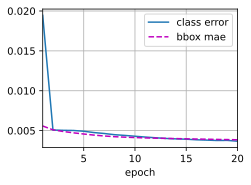

In [47]:
num_epochs, timer = 20, d2l.Timer()
animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                        legend=['class error', 'bbox mae'])
net = net.to(device)
for epoch in range(num_epochs):
    # 训练精确度的和，训练精确度的和中的示例数
    # 绝对误差的和，绝对误差的和中的示例数
    metric = d2l.Accumulator(4)
    net.train()
    for features, target in train_iter:
        timer.start()
        trainer.zero_grad()
        X, Y = features.to(device), target.to(device)
        # 生成多尺度的锚框，为每个锚框预测类别和偏移量
        anchors, cls_preds, bbox_preds = net(X)
        # 为每个锚框标注类别和偏移量
        bbox_labels, bbox_masks, cls_labels = d2l.multibox_target(anchors, Y)
        # 根据类别和偏移量的预测和标注值计算损失函数
        l = calc_loss(cls_preds, cls_labels, bbox_preds, bbox_labels,
                      bbox_masks)
        l.mean().backward()
        trainer.step()
        metric.add(cls_eval(cls_preds, cls_labels), cls_labels.numel(),
                   bbox_eval(bbox_preds, bbox_labels, bbox_masks),
                   bbox_labels.numel())
    cls_err, bbox_mae = 1 - metric[0] / metric[1], metric[2] / metric[3]
    animator.add(epoch + 1, (cls_err, bbox_mae))
print(f'class err {cls_err:.2e}, bbox mae {bbox_mae:.2e}')
print(f'{len(train_iter.dataset) / timer.stop():.1f} examples/sec on '
      f'{str(device)}')

备注——关于CUDA和MPS学习率问题：
- 同样在lr=0.2的情况下，使用CUDA正常收敛，而使用MPS则完全不收敛；
- 相比CUDA，使用MPS计算时，lr应调低；
- MPS浮点行为和CUDA不一样，Apple GPU的FP32实现细节不同，某些reduction operation精度会差，导致detection loss更容易震荡，对于SSD多任务损失，学习率的问题被进一步放大。